In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

import tiktoken

In [2]:
tokenizer = tiktoken.get_encoding("cl100k_base") # GPT4 tokenizer

In [3]:
# data hyperparameters
context_size = 8 # sequence length
stride = 2 # how many tokens to skip between sequences
n_vocab = tokenizer.n_vocab

# model hyperparameters
batch_size = 5
embedding_dim = 64

In [4]:
# get raw text of the Time Machine by H.G. Wells
url = 'https://www.gutenberg.org/files/35/35-0.txt'
response = requests.get(url)
text = response.text

tokens = tokenizer.encode(text)
tokens_tensor = torch.tensor(tokens, dtype=torch.long)

print(f"Number of tokens in the dataset: {len(tokens_tensor)}")

Number of tokens in the dataset: 43053


In [5]:
class TextDataset(Dataset):
    def __init__(self, tokens_tensor, context_size=8, stride=2):
        

        # build all windows at once using unfold
        self.inputs  = tokens_tensor.unfold(0, context_size, stride)       # (num_windows, context_size)
        self.targets = tokens_tensor[1:].unfold(0, context_size, stride)    # shifted by 1

        # make sure both have the same number of windows
        min_len = min(len(self.inputs), len(self.targets))
        self.inputs  = self.inputs[:min_len]
        self.targets = self.targets[:min_len]

    def __len__(self):
        return len(self.inputs)  # number of windows, not tokens

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]  # each is (context_size,)
    
token_dataset = TextDataset(tokens_tensor, context_size, stride)
token_dataset[4]

(tensor([ 9745,    38,   469, 37725,   220,  1758, 17601,   881]),
 tensor([   38,   469, 37725,   220,  1758, 17601,   881,  8731]))

In [6]:
token_dataloader = DataLoader(token_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_size):
        super().__init__()

        # embedding layer to convert word indices to embeddings (for example token 1234 will be mapped to a vector of size embedding_dim)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # unembedding (linear layer) to convert the output of the model back to vocab size logits
        self.gelu = nn.GELU() # 
        self.fc1 = nn.Linear(embedding_dim, vocab_size, bias=False) 

    def forward(self, tok_x):
        # tok_x: (batch_size, context_size) — token indices

        # the operation applied here is a simple lookup in the embedding matrix, so it's very efficient. 1 token index -> 1 embedding vector
        embedded = self.embedding(tok_x) # each token index is mapped to a vector of size embedding_dim
        # embedded: (batch_size, context_size, embedding_dim)

        activated = self.gelu(embedded) # apply non-linearity
        # activated: (batch_size, context_size, embedding_dim)
        
        out = self.fc1(activated) # project back to vocab size
        # out: (batch_size, context_size, vocab_size) — raw logits

        return out

    def generate_greedy(self, tok_x, max_new_tokens):
        # this is called "greedy decoding" because at each step we pick the most likely next token, without any randomness or sampling. 
        # This is a simple but effective decoding strategy for text generation.
        
        # tok_x: (batch_size, context_size) — token indices

        for _ in range(max_new_tokens):
            
            out = self.forward(tok_x) # get the model's predictions for the next token 
            # out: (batch_size, context_size, vocab_size)
            
            next_token_logits = out[:, -1, :] # we only care about the last token's logits, since that's what we'll use to predict the next token
            # next_token_logits: (batch_size, vocab_size)
            
            # we don't apply softmax here because torch.argmax will give the same result whether we apply it or not, and it's more efficient to work with raw logits
            next_token = torch.argmax(next_token_logits, dim=1) # get the index of the most likely next token
            # next_token: (batch_size,)
            
            next_token = next_token.unsqueeze(1) # reshape to (batch_size, 1) so we can concatenate it to the input sequence
            # next_token: (batch_size, 1)
            
            tok_x = torch.cat([tok_x, next_token], dim=1) # append the predicted token to the input sequence
            # tok_x: (batch_size, context_size + 1) after the first iteration, then (batch_size, context_size + 2), etc.

        return tok_x # return the full sequence including the original context and the newly generated tokens
        #return tok_x[:, -max_new_tokens:] # return only the newly generated tokens
    
    def generate_sample(self, tok_x, max_new_tokens):
        # This approach treats the model's output as a probability distribution. If the word "apple" has a 70% chance and "banana" 
        # has a 20% chance, the model will actually pick "banana" about 1/5th of the time.
        # This is called "sampling decoding" because at each step we sample the next token from the probability distribution defined
        # by the model's output logits, rather than always picking the most likely token. 
        # This can lead to more diverse and creative text generation, but it can also produce less coherent results if the sampling is too random.
        
        for _ in range(max_new_tokens):
            
            out = self.forward(tok_x) # get the model's predictions for the next token 
            # out: (batch_size, context_size, vocab_size)
            
            next_token_logits = out[:, -1, :] # we only care about the last token's logits, since that's what we'll use to predict the next token
            # next_token_logits: (batch_size, vocab_size)
            
            # apply softmax to convert logits to probabilities
            next_token_probs = F.softmax(next_token_logits, dim=1) 
            # next_token_probs: (batch_size, vocab_size)
            
            # sample the next token from the probability distribution
            next_token = torch.multinomial(next_token_probs, num_samples=1)
            # next_token: (batch_size, 1) — we sample one token for each example in the batch
                        
            tok_x = torch.cat([tok_x, next_token], dim=1) # append the predicted token to the input sequence

        return tok_x

model = GPTModel(n_vocab, embedding_dim, context_size)
print(model)

GPTModel(
  (embedding): Embedding(100277, 64)
  (gelu): GELU(approximate='none')
  (fc1): Linear(in_features=64, out_features=100277, bias=False)
)


Input batch shape: torch.Size([8])
Target batch shape: torch.Size([8])
Output shape: torch.Size([8, 100277])
Sampled token index: 72289


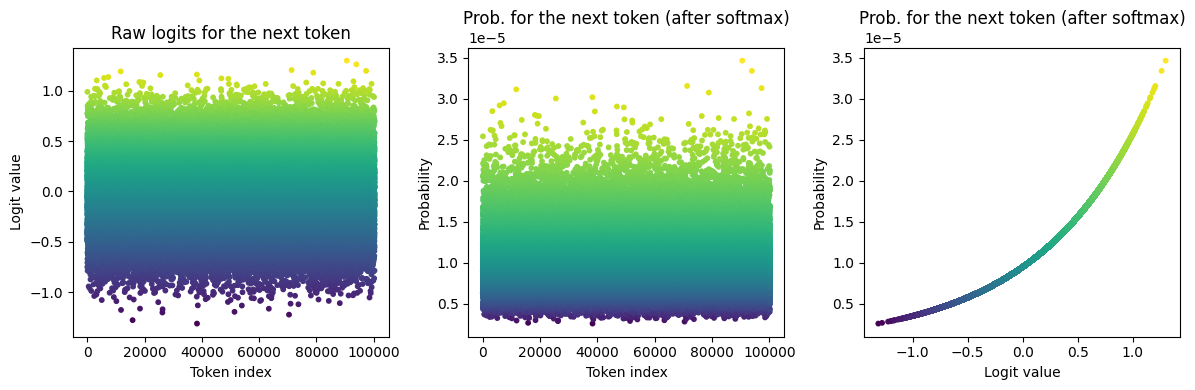

In [27]:
# test the model's forward pass

X_batch, y_batch = token_dataset[1234] # get one sequence of data (not a batch yet)
print("Input batch shape:", X_batch.shape) # should be (context_size)
print("Target batch shape:", y_batch.shape) # should be (context_size)
out = model(X_batch) # forward pass
print("Output shape:", out.shape) # should be (context_size, vocab_size)
# here we are only passing a single sequence (not a batch) to the model, to try to predict the next token for that sequence

final = out[-1, :].detach() # get the logits for the last token in the sequence, which is what we'll use to predict the next token
softmaxed = F.softmax(final, dim=0) # apply softmax to get probabilities

# use multinomial sampling to sample a token from the probability distribution
# This approach treats the model's output as a probability distribution. If the word "apple" has a 70% chance and "banana" 
# has a 20% chance, the model will actually pick "banana" about 1/5th of the time.
sampled_token = torch.multinomial(softmaxed, num_samples=1) # this will give us a tensor of shape (1,) containing the index of the sampled token
print("Sampled token index:", sampled_token.item())

# visualize the raw logits and the probabilities for the next token
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].scatter(range(n_vocab), final, s=10, c=final)
axs[0].set_title("Raw logits for the next token")
axs[0].set_xlabel("Token index")
axs[0].set_ylabel("Logit value")
axs[1].scatter(range(n_vocab), softmaxed, s=10, c=final)
axs[1].set_title("Prob. for the next token (after softmax)")
axs[1].set_xlabel("Token index")
axs[1].set_ylabel("Probability")
axs[2].scatter(final, softmaxed, s=10, c=final)
axs[2].set_title("Prob. for the next token (after softmax)")
axs[2].set_xlabel("Logit value")
axs[2].set_ylabel("Probability")
plt.tight_layout()
plt.show()

# the last graph is just to represent the non-linearity of the softmax function, which converts
# the raw logits (which can be any real number) into probabilities (which are between 0 and 1 and sum to 1 across all tokens)
# we can see that the relatively small logit values get surpressed to near zero probabilities, while the larger logit values get boosted to much higher probabilities, 
# which is what allows the model to make a clear prediction for the next token.

In [36]:
# try generating text with the model (this will be random since the model is untrained, but it should run without errors)
# RUN IT multiple times, greedy will always give the same output, while sampling will give different outputs each time

X_batch, y_batch = token_dataset[1234] # get one sequence of data (not a batch yet)

# try greedy approach
generated_tokens = model.generate_greedy(X_batch.unsqueeze(0), max_new_tokens=10) # add batch dimension and generate 10 new tokens
generated_text = tokenizer.decode(generated_tokens[0].tolist()) # decode the generated token indices back to text
print("Generated text:", generated_text)

# try sampling approach
generated_tokens_sample = model.generate_sample(X_batch.unsqueeze(0), max_new_tokens=10) # add batch dimension and generate 10 new tokens
generated_text_sample = tokenizer.decode(generated_tokens_sample[0].tolist()) # decode the generated token indices back to text
print("Generated text (sampling):", generated_text_sample)

Generated text: 
framework, scarcely larger than a smallTênancias QtWidgetsPhi__("RequestMappingumper dollStampISH
Generated text (sampling): 
framework, scarcely larger than a small.skills CZ gslenuity pedal persec_requirements CarlsonIFDEFchild
